In [14]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import math

In [9]:
img = cv2.imread('../image/bank4.jpg',0)
print(type(img))

<class 'numpy.ndarray'>


In [15]:
def histogram(img):
    row, col = img.shape
    hist = [0.0] * 256
    for i in range(row):
        for j in range(col):
            hist[img[i, j]]+=1
    return np.array(hist)

In [16]:
def ResizeImage(img, scale):
    row, col = img.shape
    dim = (int(col*scale), int(row*scale))
    return cv2.resize(img, dim, interpolation = cv2.INTER_AREA)

In [17]:
def ShowImage(img):
    plt.axis("off")
    plt.imshow(img, cmap='gray')
    plt.show()

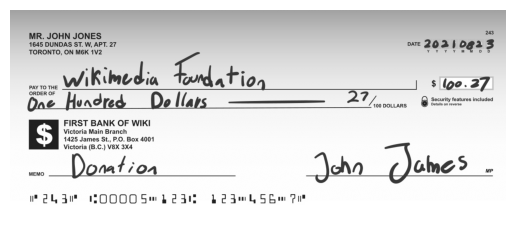

In [18]:
ShowImage(img)

In [19]:
hist = histogram(img)
print(hist.shape)

(256,)


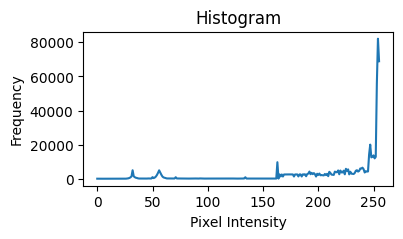

In [20]:
plt.figure(figsize=(4,2))
plt.plot(hist)
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.show()
# plt.savefig('histogram.png')

In [21]:
thresh = 30 # int(np.mean(img))
print(thresh)

30


In [22]:
Tot = np.sum(hist)
print(Tot, img.shape[0]*img.shape[1])

prob = hist/Tot

616800.0 616800


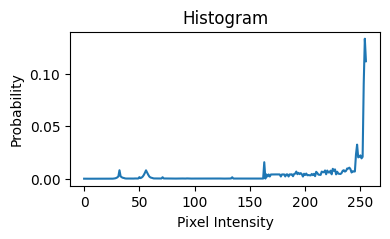

1.0


In [23]:
plt.figure(figsize=(4,2))
plt.plot(prob)
plt.title('Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Probability')
plt.show()

print(np.sum(prob))

In [25]:
print(prob.sum())

1.0


In [28]:
w0 = np.sum(prob[:thresh]) + 0.00000001
w1 = np.sum(prob[thresh:]) + 0.00000001

u0 = 0
for i in range(thresh) :
    u0 += i*prob[i]
u0 /= w0
print(f"u0 : {u0}")

u1 = 0
for i in range(thresh) :
    u1 += i*prob[i]
u1 /= w1
print(f"u1 : {u1}")

u0 : 27.1261414612151
u1 : 0.03694876749031189


In [29]:
def intermean(hist, t):
    prob = hist/np.sum(hist)
    
    w0 = np.sum(prob[:t]) + 0.00000001
    w1 = np.sum(prob[t:]) + 0.00000001
    
    u0 = np.sum(np.array([i for i in range(t)])*prob[:t])/w0
    u1 = np.sum(np.array([i for i in range(t,256)])*prob[t:])/w1
    if (u0 == 0.0):
        thr = u1
    elif (u1 == 0.0):
        thr = u0
    else:
        thr = (u0 +u1) / 2

    return thr.astype('int16')